In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/car_data_27-08-2025_17_56_32.csv')
print(df.shape)

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['age'] = 2025 - df['year']

df['volume'] = pd.to_numeric(
    df['volume'].str.replace(' cm3', '', regex=False),
    errors='coerce'
)

# Convert 'price' to numeric, forcing non-numeric to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows where 'price' is NaN (i.e., was non-numeric)
df = df.dropna(subset=['price'])


df.info()

df['fuel'].value_counts()

(23106, 22)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 22324 entries, 0 to 23105
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DMFW            5945 non-null   object 
 1   ID              22324 non-null  float64
 2   URL             22324 non-null  object 
 3   bodywork        22324 non-null  object 
 4   brand           22324 non-null  object 
 5   color           22324 non-null  object 
 6   country_origin  6453 non-null   object 
 7   date_posted     22324 non-null  object 
 8   door            22321 non-null  object 
 9   emission        22317 non-null  object 
 10  fixed_price     22324 non-null  object 
 11  fuel            22324 non-null  object 
 12  mileage         21197 non-null  float64
 13  model           22323 non-null  object 
 14  origin          22319 non-null  object 
 15  power           22324 non-null  float64
 16  price           22324 non-null  float64
 17  registered      223

Dizel                      13716
Benzin                      6735
Benzin + Gas (TNG)           621
Benzin + Metan (CNG)         382
Hibridni pogon (Benzin)      350
Električni pogon             227
Hibridni pogon               162
Hibridni pogon (Dizel)       105
Plug-in hibrid                26
Name: fuel, dtype: int64

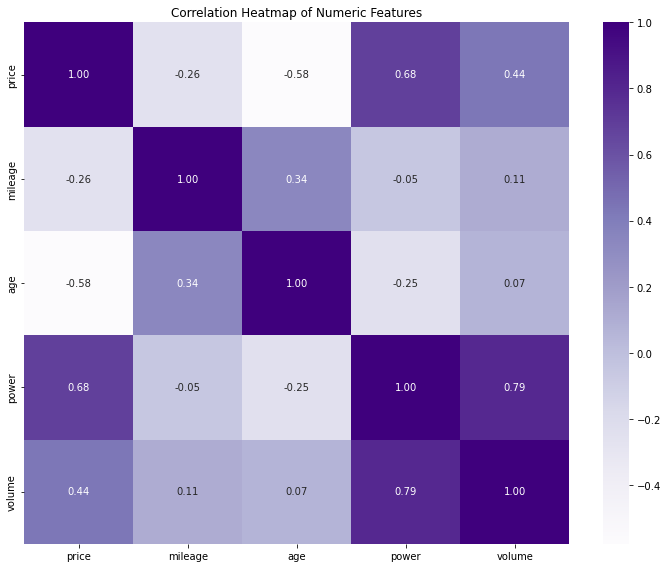

In [6]:
numeric_cols = ['price', 'mileage', 'age', 'power', 'volume']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Purples", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

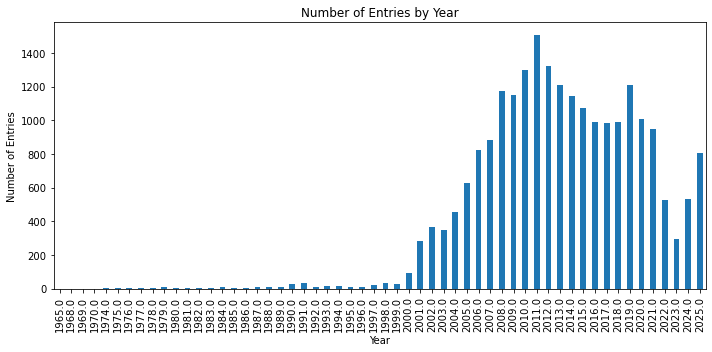

In [7]:
entries_per_year = df.groupby('year').size()

# Plot
entries_per_year.plot(kind='bar', figsize=(10, 5), title='Number of Entries by Year')
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.tight_layout()
plt.show()

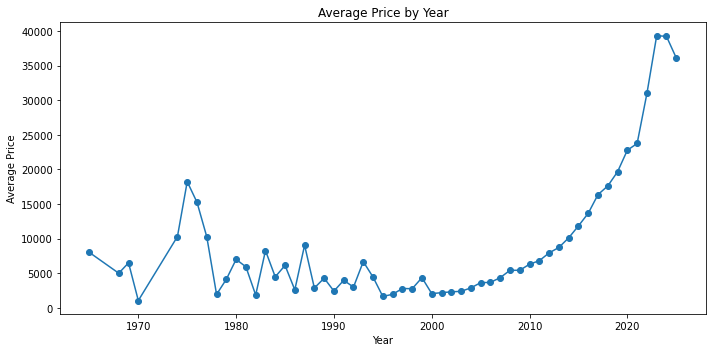

In [8]:
# Group by year and compute average price
avg_price_per_year = df.groupby('year')['price'].mean()

# Plot
avg_price_per_year.plot(kind='line', marker='o', figsize=(10, 5), title='Average Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()


In [9]:
grouped = df.groupby('brand')

# Number of cars per brand
car_counts = grouped.size()

# Average price per brand
avg_price_brand = grouped['price'].mean()

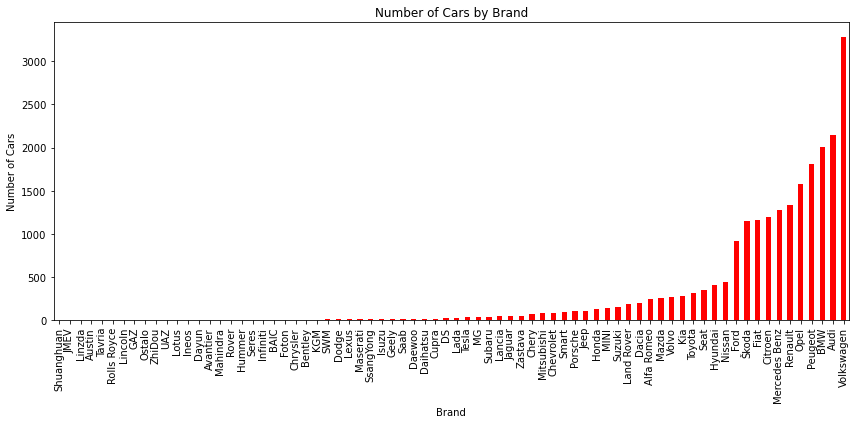

In [10]:
plt.figure(figsize=(12, 6))

car_counts = df["brand"].value_counts()
car_counts = car_counts.sort_values(ascending=True)

car_counts.plot(kind='bar', color='red')
plt.title('Number of Cars by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


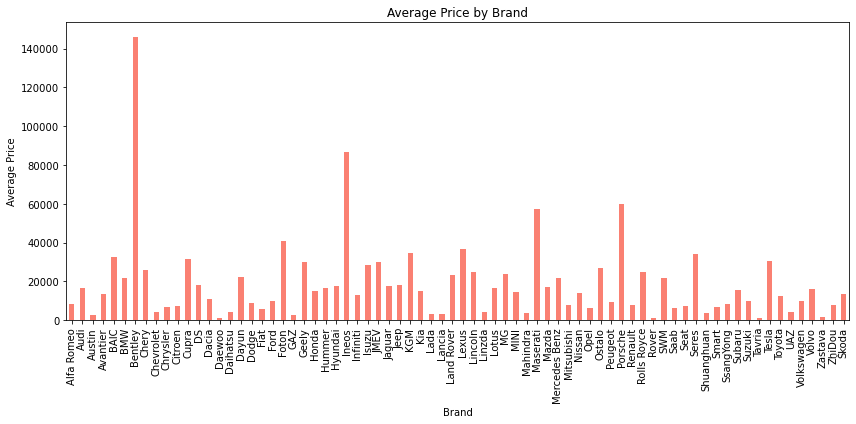

In [11]:
plt.figure(figsize=(12, 6))
avg_price_brand.plot(kind='bar', color='salmon')
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


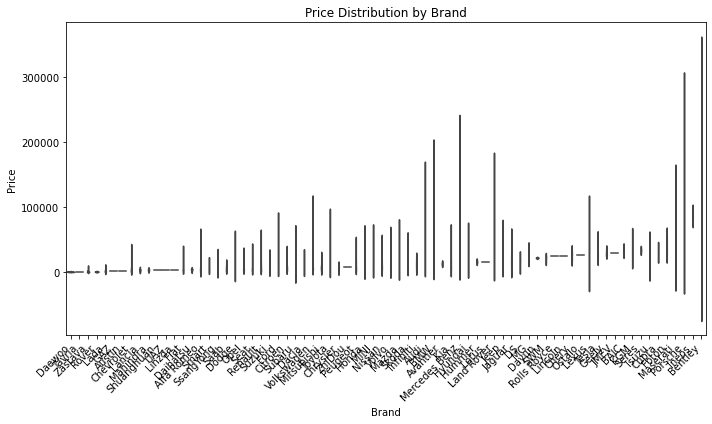

In [12]:
order = df.groupby("brand")["price"].median().sort_values().index

plt.figure(figsize=(10,6))
sns.violinplot(x="brand", y="price", data=df, order=order, inner="quartile")
plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

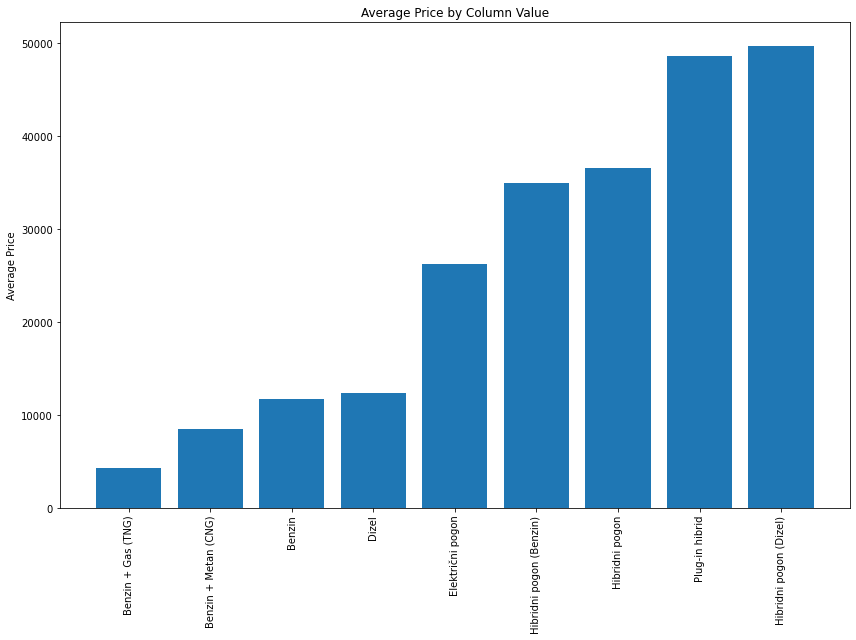

In [19]:
avg_prices = df.groupby('fuel')['price'].mean().sort_values()

plt.figure(figsize=(12, 9))
plt.bar(avg_prices.index, avg_prices.values)
plt.xticks(rotation=90)
plt.ylabel("Average Price")
plt.title("Average Price by Column Value")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

groups = df.groupby('fuel')['price']
grand_mean = df['country_origin'].mean()

# Between-group variability
ss_between = sum(g.size * (g.mean() - grand_mean)**2 for _, g in groups)

# Total variability
ss_total = sum((df['price'] - grand_mean)**2)

eta_squared = ss_between / ss_total
print("η² =", eta_squared)


η² = 0.10853594660637858
